# Notebook 01: Synthetic Ellipse Case Study

**Obstacle-Aware Clustering for Geographic Data**

Standard k-means uses Euclidean distance, which ignores geographic obstacles. Points on opposite sides of a barrier can end up in the same cluster simply because their straight-line distance is small, even though the practical distance around the obstacle is longer. In this notebook, we demonstrate the issue using a synthetic elliptical obstacle and show how a loop-aware arc-length parameter corrects it before we move on to real-world data in later notebooks.

---


## 1. Setup

In [1]:
import os
# Prevent sklearn/kmeans from spawning parallel threads on Windows
os.environ['OMP_NUM_THREADS'] = '1'
# Suppress the Intel/LLVM OpenMP duplicate-library warning on conda + Windows
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# Our custom package
from obstacle_clustering import (
    EllipseBoundary, ObstacleKMeans,
    loop_aware_distance
)

# --- Plot style ---
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 13,
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 22,
})
# Consistent cluster colors for all plots
CLUSTER_COLORS = ['#e74c3c', '#3498db', '#2ecc71']

## 2. Defining the Obstacle

We define our obstacle as the level set of a 2D Gaussian function at threshold $c$:

$$A \cdot \exp\!\left(-\frac{(x-h)^2}{2\sigma_x^2} - \frac{(y-k)^2}{2\sigma_y^2}\right) = c$$

Setting $f(x,y) = c$ picks out a specific contour line of the Gaussian, which is the boundary of the obstacle. Taking the log of both sides and rearranging puts it in the standard ellipse form with semi-axes:

$$a = \sigma_x\sqrt{-2\ln(c/A)}, \qquad b = \sigma_y\sqrt{-2\ln(c/A)}$$

Using the identity $\cos^2(t) + \sin^2(t) = 1$, we can write the ellipse parametrically:

$$x(t) = \sigma_x \sqrt{-2\ln(c/A)}\,\cos(t) + h, \qquad y(t) = \sigma_y \sqrt{-2\ln(c/A)}\,\sin(t) + k$$

for $t \in [0, 2\pi]$. This parametric form gives us a single variable $t$ that tracks position along the boundary, which we need for computing arc lengths later on.

Semi-axis a (horizontal): 9.10
Semi-axis b (vertical):   1.82
Total arc length: 38.26


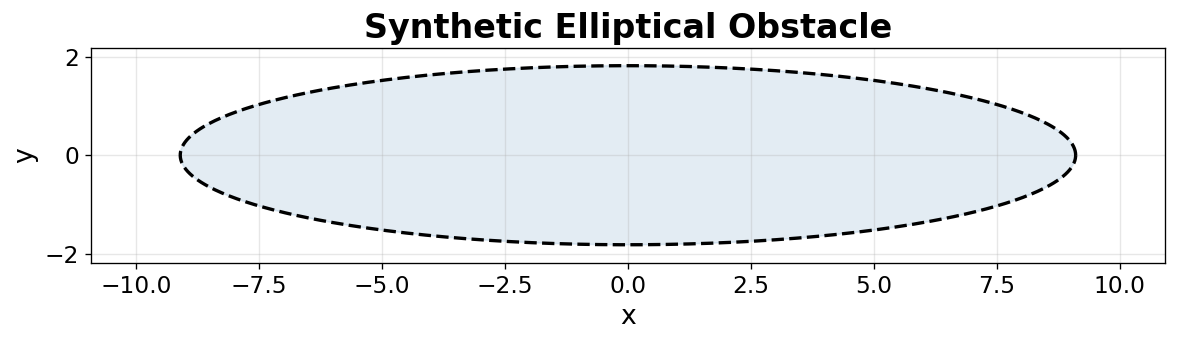

In [2]:
# Define the ellipse boundary
boundary = EllipseBoundary(
    sigma_x=3.0, sigma_y=0.6,  # 5:1 aspect ratio (wide and thin)
    h=0.0, k=0.0,              # centered at the origin
    c=0.01, A=1.0              # level-set threshold and Gaussian peak
)

# Pull out semi-axes and perimeter
L = boundary.total_arc_length()
a = boundary.sigma_x * boundary.sqrt_term  # horizontal semi-axis
b = boundary.sigma_y * boundary.sqrt_term  # vertical semi-axis
print(f'Semi-axis a (horizontal): {a:.2f}')
print(f'Semi-axis b (vertical):   {b:.2f}')
print(f'Total arc length: {L:.2f}')

# Sample points along the boundary for plotting (reused in later cells)
boundary_pts = boundary.sample_boundary(500)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=2)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.15, color='steelblue')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Synthetic Elliptical Obstacle')
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.margins(0.1)
plt.tight_layout()
plt.show()

## 3. Generating Synthetic Data

We generate three clusters of 5 points each, placed outside the ellipse to simulate locations scattered around three sides of the obstacle:

- **North-east side**: Points above the ellipse, spread along the right half
- **South-east side**: Points below the ellipse, in a similar x-range
- **West side**: Points around the left tip of the ellipse

The north-east and south-east clusters overlap in their x-range but sit on opposite sides of the obstacle. Near the right end where the ellipse narrows, some of these points are close in straight-line distance even though the obstacle separates them. This is the setup that will cause standard k-means to fail.

In [3]:
def generate_synthetic_data(seed=67):
    np.random.seed(seed)
    noise_std = 0.12  # small Gaussian jitter so points aren't on a perfect grid
    
    # North-east side: above the ellipse, right half
    north = np.array([
        [1.0, 2.5],
        [3.0, 2.3],
        [5.0, 2.1],
        [6.5, 1.8],
        [7.5, 1.4],
    ]) + np.random.normal(0, noise_std, (5, 2))
    
    # South-east side: below the ellipse, same x-range
    south = np.array([
        [1.0, -2.5],
        [3.0, -2.3],
        [5.0, -2.1],
        [6.5, -1.8],
        [7.5, -1.4],
    ]) + np.random.normal(0, noise_std, (5, 2))
    
    # West side: around the left tip
    west = np.array([
        [-10.0, 1.0],
        [-10.5, 0.0],
        [-10.0, -1.0],
        [-9.5, 1.5],
        [-9.5, -1.5],
    ]) + np.random.normal(0, noise_std, (5, 2))
    
    raw_data = np.vstack([north, south, west])
    true_labels = np.array([0]*5 + [1]*5 + [2]*5)
    
    return raw_data, true_labels


# seed=67 produces exactly one point close enough to the obstacle
# for standard k-Means to misassign it
raw_data, true_labels = generate_synthetic_data(seed=67)
print(f'Generated {len(raw_data)} points across 3 clusters (shape: {raw_data.shape})')

Generated 15 points across 3 clusters (shape: (15, 2))


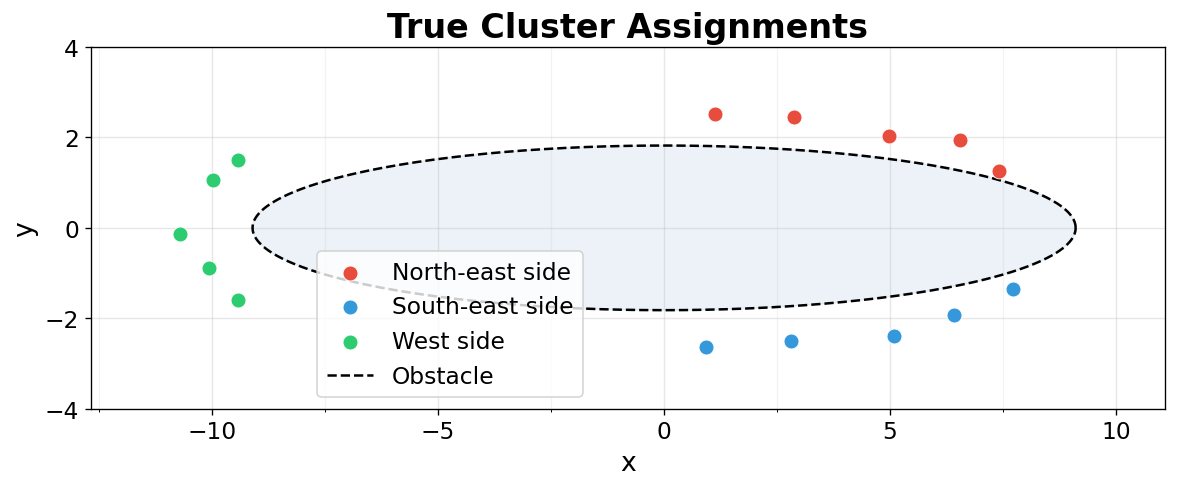

In [4]:
# Plot data colored by true cluster
fig, ax = plt.subplots(figsize=(10, 6))

labels_text = ['North-east side', 'South-east side', 'West side']

for i in range(3):
    mask = true_labels == i
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=CLUSTER_COLORS[i],
              s=80, edgecolors='white', linewidth=0.5, label=labels_text[i], zorder=3)

# Draw the ellipse
ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('True Cluster Assignments')
ax.legend(loc='lower left', bbox_to_anchor=(0.2, 0))
ax.set_aspect('equal')
ax.set_ylim(-4, 4)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))   # 2 = one minor per major interval
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.margins(0.1)
plt.tight_layout()
plt.show()

## 4. Failure of Standard k-means

Standard k-means iterates between two steps until centroids stop moving:

1. **Initialize**: Pick $k$ initial centroids (we use k-means++).
2. **Assign**: For each data point, calculate the Euclidean distance to each centroid in $(x, y)$. Assign the point to the nearest one.
3. **Update**: For each cluster, set the new centroid to the mean of the cluster members' $(x, y)$ positions.
4. **Repeat**: Steps 2 and 3 until centroids stop moving.

Because the assignment step uses Euclidean distance, the algorithm treats the space as unobstructed. Near the right end of the ellipse where the boundary narrows, points on opposite sides of the obstacle can be closer in Euclidean distance than points on the same side but farther apart along the boundary.

In [5]:
# Run standard k-means on (x, y)
# random_state=2 combines with data seed=67 to give exactly one misassignment
kmeans_standard = KMeans(n_clusters=3, random_state=2, n_init=10)
labels_standard = kmeans_standard.fit_predict(raw_data)
print(f'Standard k-means converged in {kmeans_standard.n_iter_} iterations')

# Check cluster composition against true labels
print('Standard k-means cluster composition:')
for i in range(3):
    members = np.where(labels_standard == i)[0]
    comp = [np.sum(true_labels[members] == j) for j in range(3)]
    print(f'  Cluster {i+1}: north-east={comp[0]}, south-east={comp[1]}, west={comp[2]}')

# Cluster labels from k-means don't correspond to true labels directly,
# so we find which true cluster dominates each k-means cluster and flag
# any point whose true label doesn't match that dominant class
print('\nMisassigned points:')
side_names = {0: 'north-east', 1: 'south-east', 2: 'west'}
for idx in range(len(raw_data)):
    true_c = true_labels[idx]
    std_c = labels_standard[idx]
    members_of_std = np.where(labels_standard == std_c)[0]
    dominant = np.argmax([np.sum(true_labels[members_of_std] == j) for j in range(3)])
    if true_c != dominant:
        side = side_names[true_c]
        print(f'  Point {idx} ({side} side at ({raw_data[idx,0]:.1f}, {raw_data[idx,1]:.1f}))'
              f' was grouped with the wrong cluster')

Standard k-means converged in 2 iterations
Standard k-means cluster composition:
  Cluster 1: north-east=0, south-east=4, west=0
  Cluster 2: north-east=0, south-east=0, west=5
  Cluster 3: north-east=5, south-east=1, west=0

Misassigned points:
  Point 9 (south-east side at (7.7, -1.3)) was grouped with the wrong cluster


c:\Users\mpp24\anaconda3\envs\obstacle-clustering\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


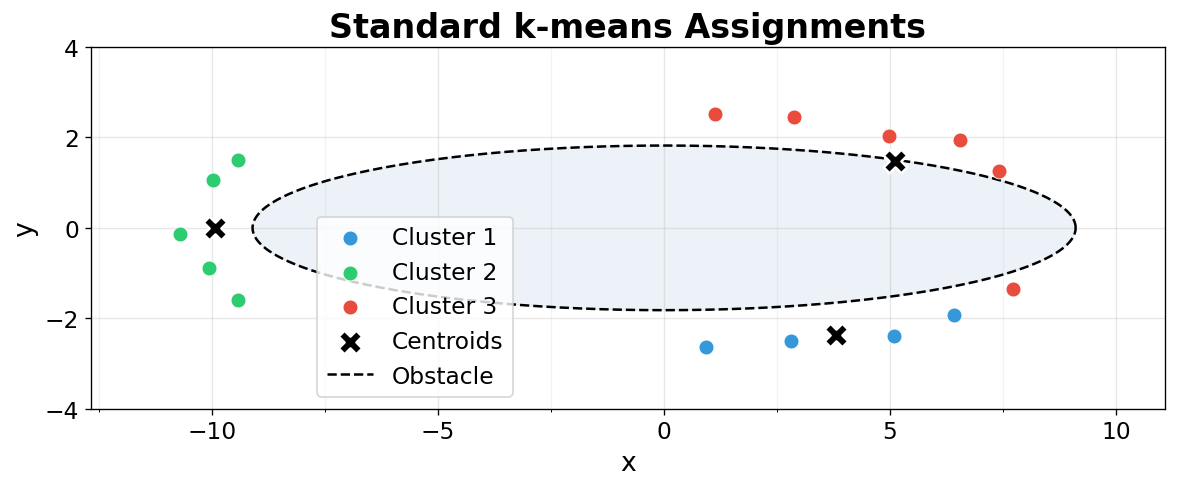

In [6]:
# Plot standard k-means result

# Helper: map each algorithm's cluster labels to the dominant true cluster
# so colors stay consistent with the true-label plot
def build_color_map(labels, true_labels, k=3):
    mapping = {}
    for alg_label in range(k):
        members = np.where(labels == alg_label)[0]
        dominant_true = np.argmax([np.sum(true_labels[members] == j) for j in range(k)])
        mapping[alg_label] = dominant_true
    return mapping

std_to_true = build_color_map(labels_standard, true_labels)

fig, ax = plt.subplots(figsize=(10, 6))

for alg_label in range(3):
    mask = labels_standard == alg_label
    color = CLUSTER_COLORS[std_to_true[alg_label]]
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=color,
              s=80, edgecolors='white', linewidth=0.5,
              label=f'Cluster {alg_label+1}', zorder=3)

ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidth=1.5,
           zorder=4, label='Centroids')

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5, label='Obstacle')
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-means Assignments')
ax.legend(loc='lower left', bbox_to_anchor=(0.2, 0))
ax.set_aspect('equal')
ax.set_ylim(-4, 4)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))   # 2 = one minor per major interval
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.margins(0.1)
plt.tight_layout()
plt.show()

## 5. The Arc-Length Parameter $s$

To encode obstacle awareness, we assign each data point a value $s \in [0, 1]$ that represents its position along the obstacle boundary. The ellipse is parameterized by $t \in [0, 2\pi]$, starting at the rightmost tip ($t = 0$) and increasing counter-clockwise.

For each data point, we:

1. **Project** it onto the nearest point on the ellipse boundary, finding the parameter value $t^*$
2. **Compute the arc length** from $t=0$ to $t^*$
3. **Normalize** by dividing by the total perimeter $L$, giving $s \in [0,1]$

Points near each other along the boundary have similar $s$ values, while points on opposite sides of the ellipse have very different $s$ values, even when they sit close in straight-line distance.

Because the boundary is a closed loop, $s=0$ and $s=1$ are the same location. We account for this with a loop-aware distance that wraps around at the seam:

$$d_s(s_1, s_2) = \min\big(|s_1 - s_2|,\; 1 - |s_1 - s_2|\big)$$

So points with $s = 0.02$ and $s = 0.98$ are correctly recognized as close.

In [7]:
# Project each data point onto the ellipse and calculate s
t_values = []
s_values = []

for x_p, y_p in raw_data:
    t_closest, s_closest = boundary.project_point(x_p, y_p)
    t_values.append(t_closest)
    s_values.append(s_closest)

t_values = np.array(t_values)
s_values = np.array(s_values)

side_lookup = {0: 'North-east', 1: 'South-east', 2: 'West'}
side_names = [side_lookup[label] for label in true_labels]

print('Arc-length values (s) for each point:')
for x, y, s, side in zip(raw_data[:, 0], raw_data[:, 1], s_values, side_names):
    print(f'  {side:10s}: ({x:6.2f}, {y:6.2f})  ->  s = {s:.4f}')

Arc-length values (s) for each point:
  North-east: (  1.14,   2.52)  ->  s = 0.2208
  North-east: (  2.87,   2.45)  ->  s = 0.1763
  North-east: (  4.98,   2.03)  ->  s = 0.1212
  North-east: (  6.54,   1.95)  ->  s = 0.0816
  North-east: (  7.40,   1.27)  ->  s = 0.0565
  South-east: (  0.94,  -2.63)  ->  s = 0.7741
  South-east: (  2.80,  -2.50)  ->  s = 0.8221
  South-east: (  5.08,  -2.39)  ->  s = 0.8802
  South-east: (  6.41,  -1.93)  ->  s = 0.9152
  South-east: (  7.71,  -1.35)  ->  s = 0.9506
  West      : ( -9.99,   1.06)  ->  s = 0.4919
  West      : (-10.70,  -0.14)  ->  s = 0.5007
  West      : (-10.07,  -0.89)  ->  s = 0.5064
  West      : ( -9.44,   1.51)  ->  s = 0.4831
  West      : ( -9.43,  -1.60)  ->  s = 0.5177


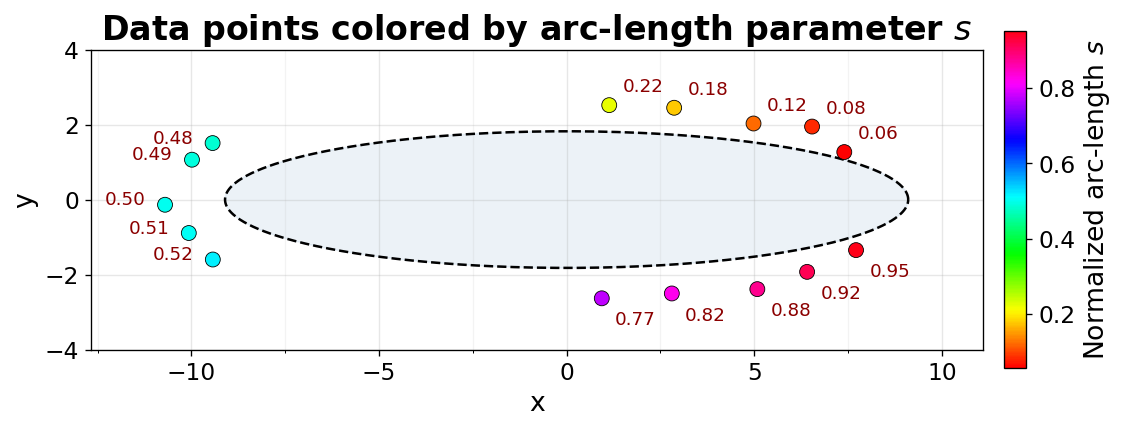

In [8]:
# Visualize points colored by their s value
fig, ax = plt.subplots(figsize=(10, 6))

# HSV colormap wraps around so s=0 and s=1 show the same color,
# reflecting that the boundary is a closed loop
scatter = ax.scatter(raw_data[:, 0], raw_data[:, 1], c=s_values, cmap='hsv',
                     s=80, edgecolors='black', linewidth=0.5, zorder=3)
plt.colorbar(scatter, ax=ax, label='Normalized arc-length $s$',
             shrink=0.5, aspect=15, pad=0.02)

# Label each point with its s value, offsetting by group so labels
# don't land on neighboring dots
# 0 = north-east (label above-right), 1 = south-east (below-right), 2 = west (left)
group_offsets = {0: (8, 8), 1: (8, -16), 2: (-36, 0)}

for (x, y), s, lbl in zip(raw_data, s_values, true_labels):
    ax.annotate(f'{s:.2f}', (x, y), textcoords='offset points',
                xytext=group_offsets[lbl], fontsize=11, color='darkred')

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Data points colored by arc-length parameter $s$')
ax.set_aspect('equal')
ax.set_ylim(-4, 4)
ax.xaxis.set_minor_locator(AutoMinorLocator(2))   # 2 = one minor per major interval
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.margins(0.1)
plt.tight_layout()
plt.show()

In [9]:
# Demonstrate loop-aware distance
print('Loop-aware distance examples:')
print(f'  d(0.05, 0.95) = {loop_aware_distance(0.05, 0.95):.2f}  (close -- wraps around the seam)')
print(f'  d(0.05, 0.50) = {loop_aware_distance(0.05, 0.50):.2f}  (far -- opposite sides)')
print(f'  d(0.30, 0.70) = {loop_aware_distance(0.30, 0.70):.2f}  (moderately far)')
print(f'  d(0.10, 0.20) = {loop_aware_distance(0.10, 0.20):.2f}  (close -- same side)')

Loop-aware distance examples:
  d(0.05, 0.95) = 0.10  (close -- wraps around the seam)
  d(0.05, 0.50) = 0.45  (far -- opposite sides)
  d(0.30, 0.70) = 0.40  (moderately far)
  d(0.10, 0.20) = 0.10  (close -- same side)


## 6. Feature Engineering

We construct the feature vector by combining the scaled $(x, y)$ coordinates with the arc-length parameter $s$:

$$\mathbf{x}_i = (x_i^{\text{scaled}},\; y_i^{\text{scaled}},\; s_i)$$

The $(x, y)$ coordinates need to be on a comparable scale with $s$, which lives in $[0, 1]$ by construction, so we normalize them to $[0, 1]$ using Min-Max scaling.

In [10]:
# Normalize x, y to [0, 1]
scaler = MinMaxScaler()
xy_scaled = scaler.fit_transform(raw_data)

# Combine into feature matrix: [x_scaled, y_scaled, s]
X = np.column_stack([xy_scaled, s_values])

print(f'Feature matrix shape: {X.shape}')
print('Features: x_scaled, y_scaled, s')

# Show north-east and south-east rows side-by-side -- their (x, y) values
# overlap but their s values are very different
print('\nFirst 5 rows (north-east side):')
print(np.array2string(X[:5], precision=4, suppress_small=True))
print('\nRows 5-9 (south-east side):')
print(np.array2string(X[5:10], precision=4, suppress_small=True))

Feature matrix shape: (15, 3)
Features: x_scaled, y_scaled, s

First 5 rows (north-east side):
[[0.6428 1.     0.2208]
 [0.7368 0.9865 0.1763]
 [0.8516 0.905  0.1212]
 [0.9364 0.8891 0.0816]
 [0.983  0.7571 0.0565]]

Rows 5-9 (south-east side):
[[0.632  0.     0.7741]
 [0.7334 0.0251 0.8221]
 [0.8572 0.0475 0.8802]
 [0.9292 0.1369 0.9152]
 [1.     0.2495 0.9506]]


## 7. Obstacle-Aware k-means

Our modified algorithm follows the same structure as standard k-means but changes the distance metric and the centroid update for $s$:

1. **Initialize**: Pick $k$ initial centroids (we use k-means++). *(same as standard)*
2. **Assign**: For each data point, calculate the **weighted composite distance** to each centroid:
   $$d^2(\mathbf{x}, \mathbf{x}') = \alpha^2 \cdot \|(x, y) - (x', y')\|^2 + \beta^2 \cdot d_s(s, s')^2$$
   where $d_s$ is the loop-aware distance on $s$. Assign the point to the nearest centroid.
3. **Update**: For each cluster:
   - Set the centroid's $(x, y)$ to the **mean of the cluster members' $(x, y)$ positions** *(same as standard)*
   - Set the centroid's $s$ via **boundary-aware projection**: average the cluster members' positions on the boundary in $(x, y)$, then project the average back onto the boundary
4. **Repeat**: Steps 2 and 3 until centroids stop moving. *(same as standard)*

The weights $\alpha$ and $\beta$ control the relative influence of geographic proximity and arc-length position. For this toy problem, we set both to 1.0. We will explore tuning these weights in the real-world applications (Notebooks 02 and 03).

Note that direct averaging of $s$ values fails on a circular domain -- for example, the mean of $s = 0.05$ and $s = 0.95$ is $0.5$, which is on the opposite side of the boundary from both points. Boundary-aware projection avoids this by averaging in $(x, y)$ space and then mapping back to $s$.

---

In [11]:
# Run obstacle-aware k-means (spatial only)
model = ObstacleKMeans(
    k=3,
    boundary=boundary,
    alpha=1.0,          # geographic weight
    beta=1.0,           # arc-length weight
    gamma=0.0,          # no attributes in this demo
    random_state=42,    # produces perfect separation on this data
    n_attr=0
)
model.fit(X, t_data=t_values)

labels_obstacle = model.labels_

print(f'Obstacle-aware k-means converged in {model.n_iter_} iterations')

print('\nObstacle-aware cluster composition:')
for i in range(3):
    members = np.where(labels_obstacle == i)[0]
    comp = [np.sum(true_labels[members] == j) for j in range(3)]
    print(f'  Cluster {i+1}: north-east={comp[0]}, south-east={comp[1]}, west={comp[2]}')

Obstacle-aware k-means converged in 2 iterations

Obstacle-aware cluster composition:
  Cluster 1: north-east=0, south-east=5, west=0
  Cluster 2: north-east=0, south-east=0, west=5
  Cluster 3: north-east=5, south-east=0, west=0


## 8. Comparison: Standard vs. Obstacle-Aware

The plot below shows the same dataset clustered two ways. The misassigned point in the standard result is correctly assigned by the obstacle-aware version.

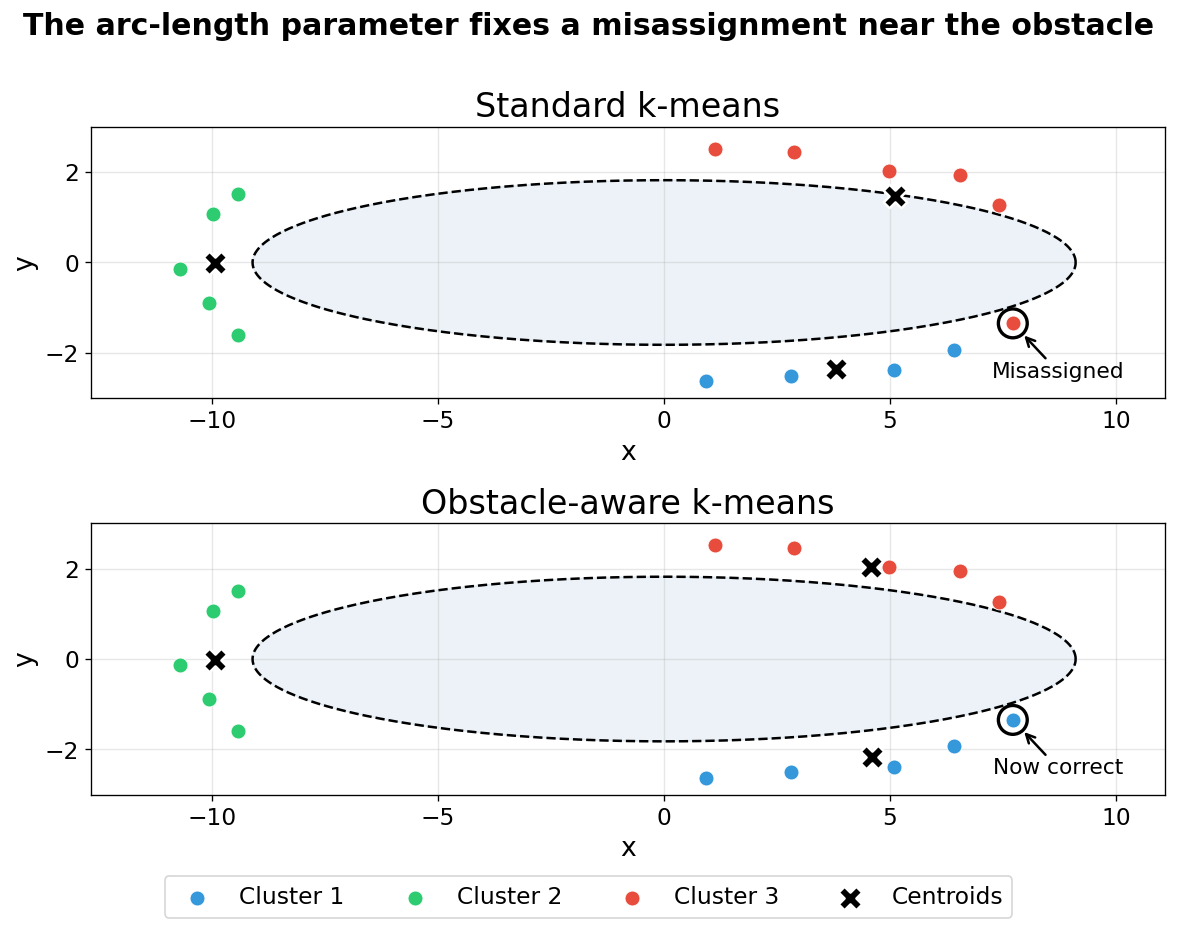

In [12]:
# Stacked comparison

# Map labels to true-cluster colors for each algorithm.
# build_color_map is defined in Cell 10.
std_to_true = build_color_map(labels_standard, true_labels)
obs_to_true = build_color_map(labels_obstacle, true_labels)

fig, axes = plt.subplots(2, 1, figsize=(10, 7.5))

# --- Standard k-means ---
ax = axes[0]
for alg_label in range(3):
    mask = labels_standard == alg_label
    color = CLUSTER_COLORS[std_to_true[alg_label]]
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=color,
              s=80, edgecolors='white', linewidth=0.5,
              label=f'Cluster {alg_label+1}', zorder=3)

ax.scatter(kmeans_standard.cluster_centers_[:, 0], kmeans_standard.cluster_centers_[:, 1],
           c='black', marker='X', s=200, edgecolors='white', linewidth=1.5,
           zorder=4, label='Centroids')

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

# Circle the misassigned point (index 9: a south-east point grouped with north-east)
misassigned_pt = raw_data[9]
ax.scatter(misassigned_pt[0], misassigned_pt[1], s=300, facecolors='none',
           edgecolors='black', linewidth=2, zorder=5)
ax.annotate('Misassigned', xy=(misassigned_pt[0], misassigned_pt[1]),
            xytext=(misassigned_pt[0]+1, misassigned_pt[1]-1.2),
            fontsize=13, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5, 
                            shrinkA=0, shrinkB=10))

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Standard k-means', fontweight='normal')
ax.set_aspect('equal')
ax.set_ylim(-3, 3)
ax.grid(True, which='major', alpha=0.3)
ax.margins(0.1)

# --- Obstacle-Aware k-means ---
ax = axes[1]
for alg_label in range(3):
    mask = labels_obstacle == alg_label
    color = CLUSTER_COLORS[obs_to_true[alg_label]]
    ax.scatter(raw_data[mask, 0], raw_data[mask, 1], c=color,
              s=80, edgecolors='white', linewidth=0.5,
              label=f'Cluster {alg_label+1}', zorder=3)
    # Centroid in raw (x, y) coordinates for plotting
    cx, cy = np.mean(raw_data[mask, 0]), np.mean(raw_data[mask, 1])
    ax.scatter(cx, cy, c='black', marker='X', s=200, edgecolors='white',
               linewidth=1.5, zorder=4)

ax.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'k--', linewidth=1.5)
ax.fill(boundary_pts[:, 0], boundary_pts[:, 1], alpha=0.1, color='steelblue')

# Circle the previously misassigned point
corrected_pt = raw_data[9]
ax.scatter(corrected_pt[0], corrected_pt[1], s=300, facecolors='none',
           edgecolors='black', linewidth=2, zorder=5)
ax.annotate('Now correct', xy=(corrected_pt[0], corrected_pt[1]),
            xytext=(corrected_pt[0]+1, corrected_pt[1]-1.2),
            fontsize=13, ha='center',
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5, 
                            shrinkA=0, shrinkB=10))

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Obstacle-aware k-means', fontweight='normal')
ax.set_aspect('equal')
ax.set_ylim(-3, 3)
ax.grid(True, which='major', alpha=0.3)
ax.margins(0.1)


plt.suptitle('The arc-length parameter fixes a misassignment near the obstacle',
             fontsize=18, fontweight='bold', y=1.0)
plt.tight_layout(rect=[0, 0.03, 1, 1])

# Shared legend below both subplots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.02))

plt.show()

## 9. Discussion

Standard k-means fails on this dataset because a south-east point sits closer in Euclidean distance to the north-east cluster than to the rest of its own. The arc-length parameter $s$ resolves this by measuring separation *around* the obstacle rather than straight through it. Once $s$ is included in the distance metric, the same point lands in the correct cluster.

This method generalizes beyond ellipses. Any smooth closed curve that can be parameterized will work, which means the same method applies to real-world boundaries once we fit them with cubic splines.

### What's Next

This notebook used a synthetic obstacle to isolate the effect of the arc-length parameter. The next two notebooks apply the same spatial method to real wildfire data, where a lake shoreline is the obstacle.

Notebook 02 works through Lake Tahoe: pulling the shoreline and fire data, fitting the boundary, and comparing standard k-means against the obstacle-aware version at two scales (the whole basin and a near-shore subset). Notebook 03 runs the same analysis on Lake Mead, a longer and narrower lake, to see how the lake's shape changes the result.